## DX799S O1 Data Science Capstone (Summer 1 2025): ACTIVITY 11.3 ##

Each week, you will apply the concepts of that week to your Integrated Capstone Project’s dataset. In preparation for Milestone Two, create a Jupyter Notebook (similar to in Module B, Semester Two) that illustrates these lessons. There are no specific questions to answer in your Jupyter Notebook files in this course; your general goal is to analyze your data using the methods you have learned about in this course and in this program and draw interesting conclusions. 

For Week 11, include concepts such as density-based spatial clustering of applications with noise (DBSCAN), hierarchical agglomerative clustering (HAC), linkage methods in HAC, and dendrograms. Complete your Jupyter Notebook homework by 11:59pm ET on Sunday. 

In Week 12, you will compile your findings from your Jupyter Notebook homework into your Milestone Two assignment for grading. For full instructions and the rubric for Milestone Two, refer to the following link. 

In [78]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.model_selection import KFold
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

In [79]:
#Video Review Dataset 

df_video_review = pd.read_csv("video_review.csv")

label_encoder = LabelEncoder()
for col in df_video_review.select_dtypes(include=['object']).columns:
    df_video_review[col] = label_encoder.fit_transform(df_video_review[col].astype(str))

X_video_review = df_video_review.drop(columns=['Primary_Impact_Type'])

scaler = StandardScaler()
X_video_review_scaled = scaler.fit_transform(X_video_review)

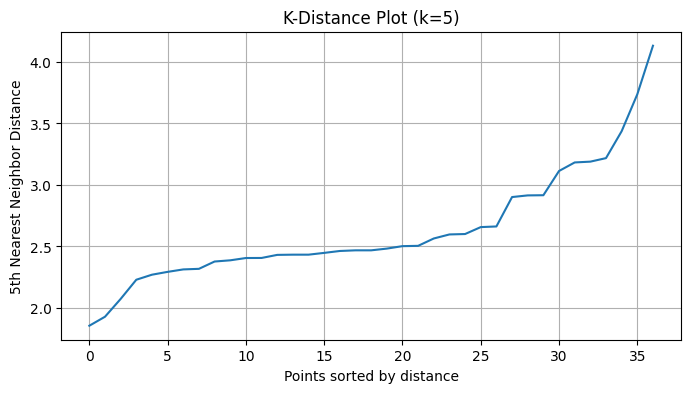

Top candidate eps values:
[2.90190684 2.91534125 2.91673972 3.11382181 3.18326615 3.18985288
 3.21841606 3.43738679 3.73762246 4.13242295]


In [80]:
# Video Review Eps

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_video_review_scaled)
distances, indices = neighbors_fit.kneighbors(X_video_review_scaled)

distances = np.sort(distances[:, 4]) 
plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title("K-Distance Plot (k=5)")
plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.grid(True)
plt.show()

print("Top candidate eps values:")
print(distances[-10:])  


In [81]:
#Video Review DBSCAN Hyperparameter Tuning
for eps in [2.0, 2.5, 2.8, 2.9, 3.0, 3.1, 3.2, 3.4]:
    db = DBSCAN(eps=eps, min_samples=5).fit(X_video_review_scaled)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    if n_clusters > 1:
        silhouette = silhouette_score(X_video_review_scaled, labels)
        print(f"eps={eps:.1f}, clusters={n_clusters}, noise={n_noise}, silhouette={silhouette:.2f}")
    else:
        print(f"eps={eps:.1f}, insufficient clusters")


eps=2.0, clusters=2, noise=27, silhouette=0.02
eps=2.5, insufficient clusters
eps=2.8, clusters=2, noise=3, silhouette=0.16
eps=2.9, clusters=2, noise=3, silhouette=0.17
eps=3.0, insufficient clusters
eps=3.1, insufficient clusters
eps=3.2, insufficient clusters
eps=3.4, insufficient clusters


In [82]:
#Video Review HAC

kf = KFold(n_splits=5, shuffle=True, random_state=42)
linkage_methods = ['single', 'complete', 'average', 'ward']

for method in linkage_methods:
    scores = []
    for train_idx, _ in kf.split(X_video_review_scaled):
        X_fold = X_video_review_scaled[train_idx]
        hac = AgglomerativeClustering(n_clusters=3, linkage=method)
        labels = hac.fit_predict(X_fold)
        score = silhouette_score(X_fold, labels)
        scores.append(score)
    print(f"Linkage={method}, Avg Silhouette={np.mean(scores):.2f}")


Linkage=single, Avg Silhouette=0.16
Linkage=complete, Avg Silhouette=0.19
Linkage=average, Avg Silhouette=0.20
Linkage=ward, Avg Silhouette=0.21


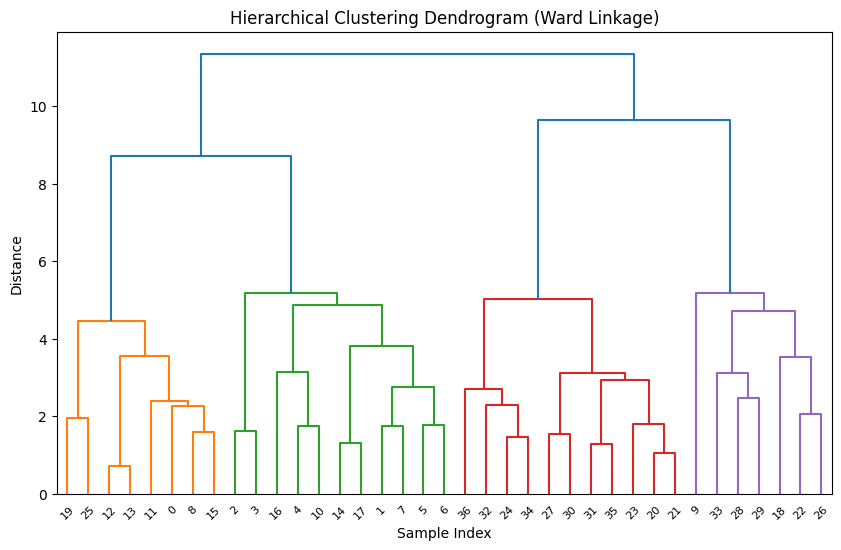

In [83]:
# Video Review Dendrogram Visualization (Ward Linkage)

plt.figure(figsize=(10, 6))
dendrogram = sch.dendrogram(sch.linkage(X_video_review_scaled, method='ward'))
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()



In [84]:
#Injury Record Dataset

injury_df = pd.read_csv("InjuryRecord.csv")

injury_label_encoder = LabelEncoder()
for col in injury_df.select_dtypes(include=['object']).columns:
    injury_df[col] = injury_label_encoder.fit_transform(injury_df[col].astype(str))

X_injury = injury_df.drop(columns=['Surface'])

injury_scaler = StandardScaler()
X_injury_scaled = injury_scaler.fit_transform(X_injury)

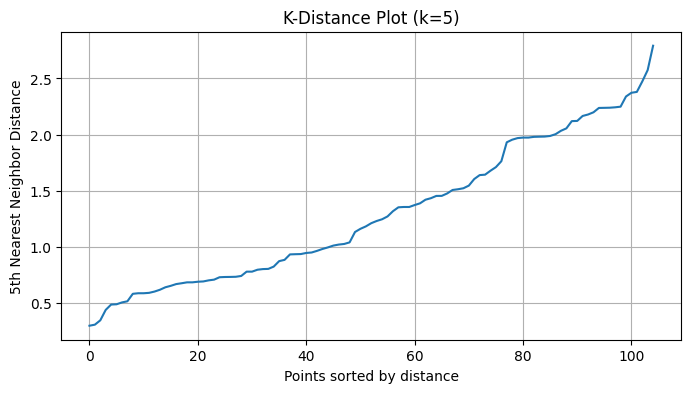

Top candidate eps values:
[2.23818234 2.23930982 2.24287558 2.24854343 2.33933353 2.37263102
 2.38017215 2.4731582  2.57510903 2.79243606]


In [85]:
# Injury Record Eps

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_injury_scaled)
distances, indices = neighbors_fit.kneighbors(X_injury_scaled)

distances = np.sort(distances[:, 4]) 
plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title("K-Distance Plot (k=5)")
plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.grid(True)
plt.show()

print("Top candidate eps values:")
print(distances[-10:])  

In [86]:
#Injury Record DBSCAN Hyperparameter Tuning

for eps in [2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7]:
    for min_samples in [5, 10]:
        dbscan_injury = DBSCAN(eps=eps, min_samples=min_samples)
        labels_injury = dbscan_injury.fit_predict(X_injury_scaled)
        n_clusters = len(set(labels_injury)) - (1 if -1 in labels_injury else 0)
        n_noise = np.sum(labels_injury == -1)
        if n_clusters > 1:
            score = silhouette_score(X_injury_scaled[labels_injury != -1], labels_injury[labels_injury != -1])
            print(f"eps={eps}, min_samples={min_samples}, clusters={n_clusters}, noise={n_noise}, silhouette={score:.2f}")
        else:
            print(f"eps={eps}, min_samples={min_samples}, insufficient clusters")


eps=2.0, min_samples=5, clusters=3, noise=12, silhouette=0.33
eps=2.0, min_samples=10, clusters=3, noise=24, silhouette=0.38
eps=2.1, min_samples=5, clusters=3, noise=8, silhouette=0.32
eps=2.1, min_samples=10, clusters=3, noise=13, silhouette=0.33
eps=2.2, min_samples=5, clusters=3, noise=1, silhouette=0.28
eps=2.2, min_samples=10, clusters=3, noise=4, silhouette=0.30
eps=2.3, min_samples=5, insufficient clusters
eps=2.3, min_samples=10, insufficient clusters
eps=2.4, min_samples=5, insufficient clusters
eps=2.4, min_samples=10, insufficient clusters
eps=2.5, min_samples=5, insufficient clusters
eps=2.5, min_samples=10, insufficient clusters
eps=2.6, min_samples=5, insufficient clusters
eps=2.6, min_samples=10, insufficient clusters
eps=2.7, min_samples=5, insufficient clusters
eps=2.7, min_samples=10, insufficient clusters


In [87]:
#Video Record HAC 

kf = KFold(n_splits=5, shuffle=True, random_state=42)
linkage_methods = ['single', 'complete', 'average', 'ward']

for method in linkage_methods:
    scores = []
    for train_idx, _ in kf.split(X_injury_scaled):
        X_fold = X_injury_scaled[train_idx]
        hac_injury = AgglomerativeClustering(n_clusters=9, linkage=method)
        labels_injury = hac_injury.fit_predict(X_fold)
        score = silhouette_score(X_fold, labels_injury)
        scores.append(score)
    print(f"Linkage={method}, Avg Silhouette={np.mean(scores):.2f}")



Linkage=single, Avg Silhouette=0.19
Linkage=complete, Avg Silhouette=0.32
Linkage=average, Avg Silhouette=0.36
Linkage=ward, Avg Silhouette=0.37


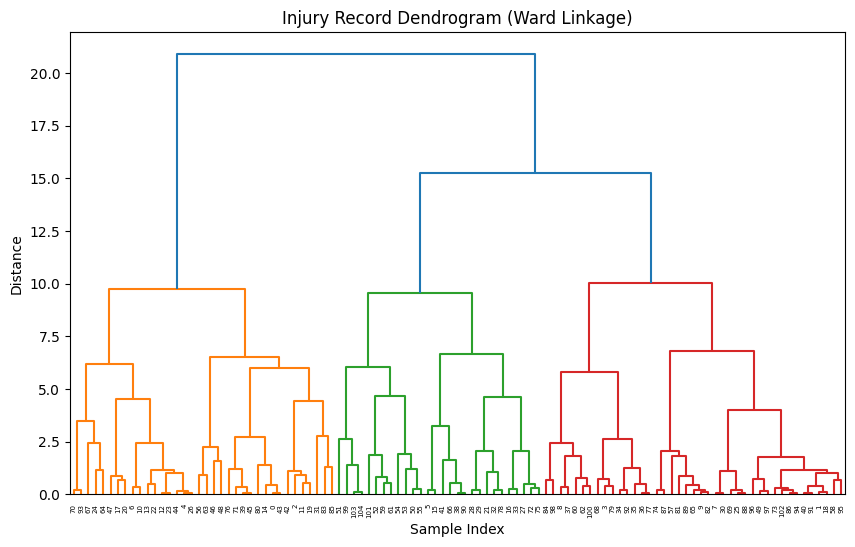

In [88]:
# Injury Record Dendrogram Visualization (Ward Linkage)

plt.figure(figsize=(10, 6))
dendrogram = sch.dendrogram(sch.linkage(X_injury_scaled, method='ward'))
plt.title("Injury Record Dendrogram (Ward Linkage)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()



In [89]:
#Concussion Dataset 

df_concussion = pd.read_csv("Concussion Injuries 2012-2014 (1).csv")
df_clean_concussion = df_concussion.drop(columns=['ID', 'Player', 'Game', 'Date', 'Winning Team?', 'Unknown Injury?'])
df_clean_concussion = df_clean_concussion.dropna()

label_encoder = LabelEncoder()
for col in df_clean_concussion.select_dtypes(include=['object']).columns:
    df_clean_concussion[col] = label_encoder.fit_transform(df_clean_concussion[col].astype(str))

X_concussion = df_clean_concussion.drop(columns=['Reported Injury Type'])

concussion_scaler = StandardScaler()
X_concussion_scaled = concussion_scaler.fit_transform(X_concussion)

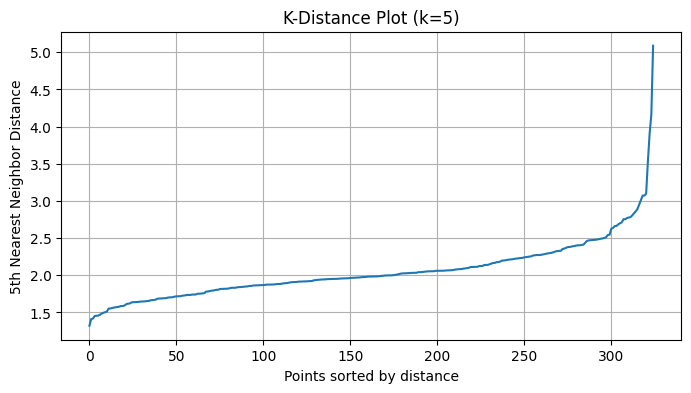

Top candidate eps values:
[2.89108729 2.95022951 3.00534996 3.07155578 3.0720409  3.09624781
 3.5276944  3.90485976 4.16623756 5.08852763]


In [90]:
# Concussion eps

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_concussion_scaled)
distances, indices = neighbors_fit.kneighbors(X_concussion_scaled)

distances = np.sort(distances[:, 4]) 
plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title("K-Distance Plot (k=5)")
plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.grid(True)
plt.show()

print("Top candidate eps values:")
print(distances[-10:])  

In [91]:
# Concussion DBSCAN Hyperparameter Tuning

for eps in [1.0, 1.40, 1.45, 1.46, 1.5, 1.6, 2.5, 2.8, 2.9, 3.0, 3.5, 4.0, 4.5, 5.1]:
    for min_samples in [5, 10]:
        dbscan_concussion = DBSCAN(eps=eps, min_samples=min_samples)
        labels_concussion = dbscan_concussion.fit_predict(X_concussion_scaled)
        n_clusters = len(set(labels_concussion)) - (1 if -1 in labels_concussion else 0)
        n_noise = np.sum(labels_concussion == -1)
        if n_clusters > 1:
            score = silhouette_score(X_concussion_scaled[labels_concussion != -1], labels_concussion[labels_concussion != -1])
            print(f"eps={eps}, min_samples={min_samples}, clusters={n_clusters}, noise={n_noise}, silhouette={score:.2f}")
        else:
            print(f"eps={eps}, min_samples={min_samples}, insufficient clusters")


eps=1.0, min_samples=5, insufficient clusters
eps=1.0, min_samples=10, insufficient clusters
eps=1.4, min_samples=5, insufficient clusters
eps=1.4, min_samples=10, insufficient clusters
eps=1.45, min_samples=5, clusters=3, noise=310, silhouette=0.49
eps=1.45, min_samples=10, insufficient clusters
eps=1.46, min_samples=5, clusters=4, noise=302, silhouette=0.45
eps=1.46, min_samples=10, insufficient clusters
eps=1.5, min_samples=5, clusters=6, noise=290, silhouette=0.37
eps=1.5, min_samples=10, insufficient clusters
eps=1.6, min_samples=5, clusters=7, noise=261, silhouette=0.21
eps=1.6, min_samples=10, insufficient clusters
eps=2.5, min_samples=5, insufficient clusters
eps=2.5, min_samples=10, insufficient clusters
eps=2.8, min_samples=5, insufficient clusters
eps=2.8, min_samples=10, insufficient clusters
eps=2.9, min_samples=5, insufficient clusters
eps=2.9, min_samples=10, insufficient clusters
eps=3.0, min_samples=5, insufficient clusters
eps=3.0, min_samples=10, insufficient cluster

In [92]:
# Concussion HAC

kf = KFold(n_splits=5, shuffle=True, random_state=42)
linkage_methods = ['single', 'complete', 'average', 'ward']

for method in linkage_methods:
    scores = []
    for train_idx, _ in kf.split(X_concussion_scaled):
        X_fold = X_concussion_scaled[train_idx]
        hac_concussion = AgglomerativeClustering(n_clusters=2, linkage=method)
        labels_concussion = hac_concussion.fit_predict(X_fold)
        score = silhouette_score(X_fold, labels_concussion)
        scores.append(score)
    print(f"Linkage={method}, Avg Silhouette={np.mean(scores):.2f}")


Linkage=single, Avg Silhouette=0.46
Linkage=complete, Avg Silhouette=0.46
Linkage=average, Avg Silhouette=0.46
Linkage=ward, Avg Silhouette=0.12


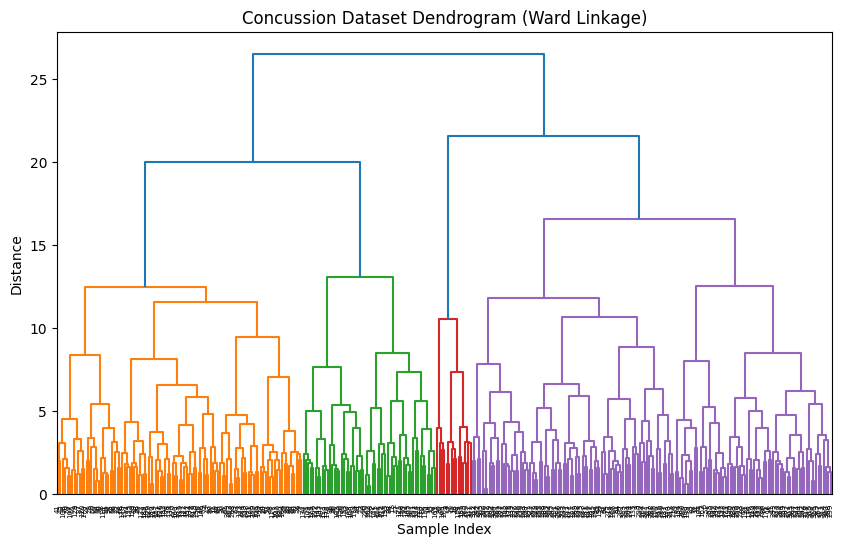

In [93]:
# Concussion Dendrogram Visualization (Ward Linkage)

plt.figure(figsize=(10, 6))
dendrogram = sch.dendrogram(sch.linkage(X_concussion_scaled, method='ward'))
plt.title("Concussion Dataset Dendrogram (Ward Linkage)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

